# IT3091 Machine Learning — Group 30 — Final Integrated Notebook

**Customer Segmentation Based on Purchasing Behaviour**
Guided Data Track · Scenario Code 0 (Retail & E-commerce)
Dataset: UCI Online Retail (ID 352) — https://archive.ics.uci.edu/dataset/352/online-retail

| Member | Contribution | Sections |
|---|---|---|
| Member 1 | Problem framing, workflow, decision log, data understanding & EDA | 1–3 |
| Member 2 | Cleaning, feature engineering, transformation & scaling | 4–5 |
| Member 3 | Baseline, three clustering methods, comparison & stability | 6–7 |
| Member 4 | Evaluation, future validation, segment naming & recommendation | 8–10 |

The notebook finds the project root by itself, so it works on any machine.

### Changes made when integrating the four members' notebooks


## 0. Setup, paths and reproducibility record

In [1]:
import os
for v in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"]:
    os.environ[v] = "1"

import hashlib, json, platform, datetime, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

SEED     = 42
SEEDS    = [42, 7, 21, 99, 123]
CUTOFF   = pd.Timestamp("2011-09-09")
FEATURES = ["Recency_scaled", "Frequency_scaled", "Monetary_scaled"]
RAW_COLS = ["Recency", "Frequency", "Monetary"]
NON_PRODUCT_CODES = {"POST", "DOT", "C2", "S"}


def find_root(start: Path) -> Path:
    for folder in [start, *start.parents]:
        if (folder / "data").is_dir() and (folder / "members").is_dir():
            return folder
    raise FileNotFoundError(
        "Project root not found. Set ROOT manually, e.g.\n"
        "ROOT = Path('/content/drive/MyDrive/WE-AI-30-ML-Assignment')")

# ROOT = Path('/content/drive/MyDrive/WE-AI-30-ML-Assignment')   # set manually if needed
ROOT = find_root(Path.cwd())

RAW_DIR, INTERIM, PROCESSED = ROOT/"data"/"raw", ROOT/"data"/"interim", ROOT/"data"/"processed"
FIGURES = ROOT/"figures"/"final"
DOCS    = ROOT/"docs"
for d in (INTERIM, PROCESSED, FIGURES, DOCS/"reproducibility"):
    d.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(FIGURES/f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Project root:", ROOT)
print("Cut-off date:", CUTOFF.date(), "| seed:", SEED)

Project root: c:\Users\vasan\OneDrive\Desktop\Machine Learning project\WE-AI-30-ML-Assignment
Cut-off date: 2011-09-09 | seed: 42


In [2]:
RAW_FILE = RAW_DIR/"Online Retail.xlsx"
if not RAW_FILE.exists():
    found = list(RAW_DIR.glob("*.xlsx")) + list(RAW_DIR.glob("*.csv"))
    if not found:
        raise FileNotFoundError(
            f"No dataset in {RAW_DIR}. Download 'Online Retail.xlsx' from "
            "https://archive.ics.uci.edu/dataset/352/online-retail and put it there.")
    RAW_FILE = found[0]

FINGERPRINT = hashlib.sha256(RAW_FILE.read_bytes()).hexdigest()
EXPECTED    = "43465a06f2ccf7c8b5bd2892bc7defb52f97487934fe93b16ae4c3936424676d"

raw = pd.read_excel(RAW_FILE, engine="openpyxl")
raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"])

print("File      :", RAW_FILE.name)
print("SHA-256   :", FINGERPRINT)
print("Matches the fingerprint recorded by Member 1:", FINGERPRINT == EXPECTED)
print("Rows, cols:", raw.shape)
print("Date range:", raw.InvoiceDate.min(), "to", raw.InvoiceDate.max())

assert raw.shape == (541909, 8), "Unexpected raw shape — is this the right file?"

(DOCS/"reproducibility"/"final_run_record.json").write_text(json.dumps({
    "dataset": "Online Retail (UCI ML Repository, ID 352)",
    "source_url": "https://archive.ics.uci.edu/dataset/352/online-retail",
    "file_name": RAW_FILE.name,
    "sha256": FINGERPRINT,
    "rows": int(raw.shape[0]), "columns": int(raw.shape[1]),
    "cutoff_date": str(CUTOFF.date()), "random_seed": SEED,
    "python": platform.python_version(),
    "pandas": pd.__version__, "numpy": np.__version__,
    "run_date": datetime.date.today().isoformat(),
}, indent=2))
print("\nRun record written to docs/reproducibility/final_run_record.json")

File      : Online Retail.xlsx
SHA-256   : 43465a06f2ccf7c8b5bd2892bc7defb52f97487934fe93b16ae4c3936424676d
Matches the fingerprint recorded by Member 1: True
Rows, cols: (541909, 8)
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00

Run record written to docs/reproducibility/final_run_record.json


## 1. Problem framing  *(Member 1)*

**Stakeholder.** The marketing manager of a UK online gift retailer.

**The problem.** The shop has thousands of customers and treats them identically.
One customer spent £279,489 across the year; the typical customer spent £657, and
roughly a third bought once and never returned. Sending everyone the same offer
wastes budget on customers who have left, and discounts customers who would have
bought anyway.

**The decision we support.** Which marketing action each customer should receive:
a loyalty reward, a win-back offer, an upsell nudge, or nothing.

**Unit of analysis.** One customer. The raw data is not organised that way — a row
is one product line on one invoice — so converting rows to customers is a core part
of the work.

**Task type.** Clustering. No column records which customers are loyal or lost, so
there is no label to train against. The computer groups customers by similarity and
we interpret the groups afterwards.

**Why this lens.** Product bundling was rejected because standard algorithms return
identical rules at the same thresholds, leaving nothing meaningful to compare.
Retention prediction was a close second but answers a narrower question. No secondary
lens was used, because the descriptor states that disconnected extra work earns nothing.

## 2. Data understanding  *(Member 1)*

A row is one product line on one invoice, not one customer and not one order.

In [3]:
print("Rows (product lines):", f"{len(raw):,}")
print("Unique invoices     :", f"{raw.InvoiceNo.nunique():,}")
print("Unique customers    :", f"{raw.CustomerID.nunique():,}")
print("Unique products     :", f"{raw.StockCode.nunique():,}")
print("Countries           :", raw.Country.nunique())

example = raw.InvoiceNo.value_counts().index[0]
print(f"\nInvoice {example} alone spans {(raw.InvoiceNo == example).sum()} rows.")

dd = pd.DataFrame({
    "Column":   raw.columns,
    "Type":     [str(t) for t in raw.dtypes],
    "Missing":  [raw[c].isna().sum() for c in raw.columns],
    "Missing %":[round(raw[c].isna().mean()*100, 2) for c in raw.columns],
    "Distinct": [raw[c].nunique() for c in raw.columns],
})
dd["Meaning"] = [
    "Invoice number; a leading 'C' marks a cancellation", "Product code", "Product name",
    "Units bought (negative = returned)", "Date and time of sale",
    "Price per unit in GBP", "Customer number", "Customer's country"]
display(dd)

Rows (product lines): 541,909
Unique invoices     : 25,900
Unique customers    : 4,372
Unique products     : 4,070
Countries           : 38

Invoice 573585 alone spans 1114 rows.


,Column,Type,Missing,Missing %,Distinct,Meaning
0,InvoiceNo,object,0,0.00,25900,Invoice number; a leading 'C' marks a cancella...
1,StockCode,object,0,0.00,4070,Product code
2,Description,object,1454,0.27,4223,Product name
3,Quantity,int64,0,0.00,722,Units bought (negative = returned)
4,InvoiceDate,datetime64[us],0,0.00,23260,Date and time of sale
5,UnitPrice,float64,0,0.00,1630,Price per unit in GBP
6,CustomerID,float64,135080,24.93,4372,Customer number
7,Country,str,0,0.00,38,Customer's country


### 2.1 Data-quality findings that drive the cleaning rules

Each finding below carries a Q-number. Every cleaning rule in section 4 cites one,
so each decision is traceable to its evidence.

In [4]:
raw["LineTotal"] = raw.Quantity * raw.UnitPrice
raw["IsCancel"]  = raw.InvoiceNo.astype(str).str.startswith("C")

spend   = raw.dropna(subset=["CustomerID"]).groupby("CustomerID").LineTotal.sum()
pos     = spend[spend > 0]
orders  = raw.dropna(subset=["CustomerID"]).groupby("CustomerID").InvoiceNo.nunique()
codes   = raw.StockCode.astype(str)
odd     = codes[~codes.str.match(r"^\d{5}")].value_counts()
top1    = pos.nlargest(max(1, int(len(pos)*0.01))).sum()

print("Non-product-looking stock codes in the raw file (Q9 evidence):")
display(odd.head(15).to_frame("rows"))

findings = pd.DataFrame([
 ["Q1",  "Missing CustomerID",  f"{raw.CustomerID.isna().sum():,} rows ({raw.CustomerID.isna().mean()*100:.1f}%)",
         "Untraceable guest sales", "Drop before customer-level work"],
 ["Q2",  "Spend skew",          f"skew {pos.skew():.1f}; top 1% = {top1/pos.sum()*100:.1f}% of revenue",
         "Wholesalers dominate raw spend", "Log-transform Monetary"],
 ["Q3",  "One-time buyers",     f"{(orders==1).sum():,} customers ({(orders==1).mean()*100:.1f}%)",
         "Two distinct populations exist", "Expect a one-time cluster"],
 ["Q7",  "Cancellations",       f"{raw.IsCancel.sum():,} rows across {raw.loc[raw.IsCancel,'InvoiceNo'].nunique():,} invoices",
         "~15% of invoices; returns are real behaviour", "Remove before counting Frequency"],
 ["Q8",  "Impossible values",   f"Quantity {raw.Quantity.min():,} to {raw.Quantity.max():,}; price min {raw.UnitPrice.min():,.2f}",
         "Accounting corrections, not sales", "Remove non-positive prices"],
 ["Q9",  "Non-product codes",   f"{odd.sum():,} rows ({', '.join(odd.index[:4])})",
         "Charges and samples, not purchases", "Remove delivery codes and samples"],
 ["Q12", "Duplicate rows",      f"{raw.duplicated().sum():,} rows ({raw.duplicated().mean()*100:.2f}%)",
         "Inflate spending totals", "Remove FIRST, before any totals"],
], columns=["Ref", "Finding", "Evidence", "Meaning", "Action taken"])
display(findings)

# Q8 correction, verified during integration:
gap = (raw.Quantity <= 0).sum() - raw.IsCancel.sum()
in_missing = ((raw.Quantity < 0) & (~raw.IsCancel) & raw.CustomerID.isna()).sum()
print(f"\nQ8 detail: {gap:,} non-positive-quantity rows carry no 'C' prefix.")
print(f"Of the negative ones, {in_missing:,} sit in rows with no CustomerID,")
print("so they are already removed by the Q1 rule. Checking negative quantity as")
print("well as the 'C' prefix is therefore harmless insurance, not a necessity.")

Non-product-looking stock codes in the raw file (Q9 evidence):


,rows
StockCode,
POST,1256
DOT,710
M,571
C2,144
D,77
S,63
BANK CHARGES,37
AMAZONFEE,34
CRUK,16


,Ref,Finding,Evidence,Meaning,Action taken
0,Q1,Missing CustomerID,"135,080 rows (24.9%)",Untraceable guest sales,Drop before customer-level work
1,Q2,Spend skew,skew 21.6; top 1% = 29.7% of revenue,Wholesalers dominate raw spend,Log-transform Monetary
2,Q3,One-time buyers,"1,313 customers (30.0%)",Two distinct populations exist,Expect a one-time cluster
3,Q7,Cancellations,"9,288 rows across 3,836 invoices",~15% of invoices; returns are real behaviour,Remove before counting Frequency
4,Q8,Impossible values,"Quantity -80,995 to 80,995; price min -11,062.06","Accounting corrections, not sales",Remove non-positive prices
5,Q9,Non-product codes,"2,995 rows (POST, DOT, M, C2)","Charges and samples, not purchases",Remove delivery codes and samples
6,Q12,Duplicate rows,"5,268 rows (0.97%)",Inflate spending totals,"Remove FIRST, before any totals"



Q8 detail: 1,336 non-positive-quantity rows carry no 'C' prefix.
Of the negative ones, 1,336 sit in rows with no CustomerID,
so they are already removed by the Q1 rule. Checking negative quantity as
well as the 'C' prefix is therefore harmless insurance, not a necessity.


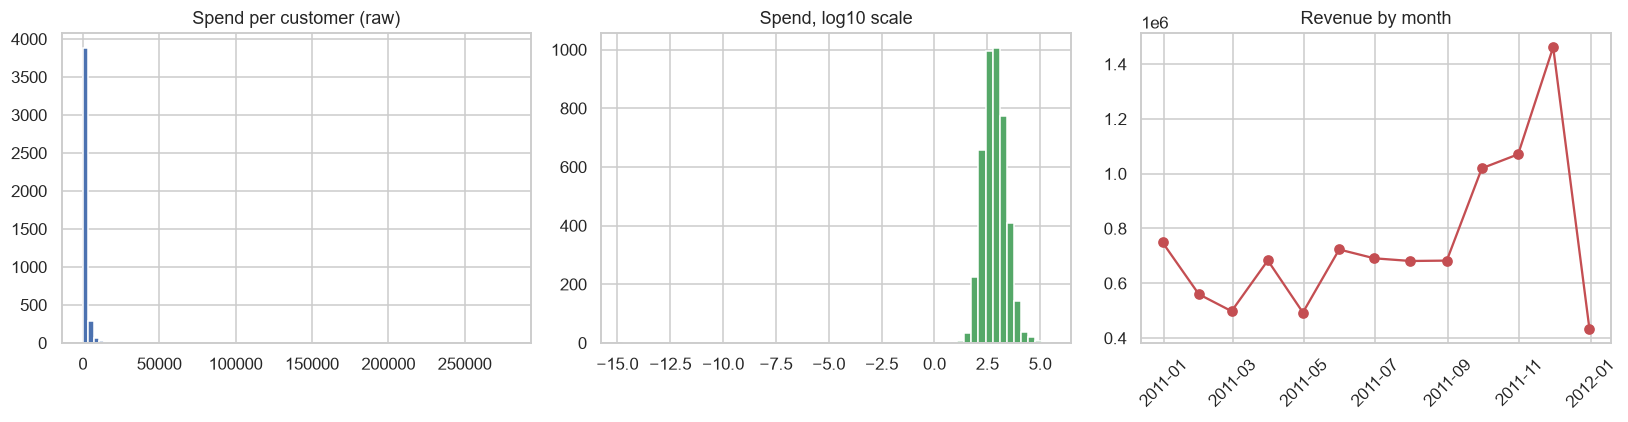

Revenue peaks in November (Christmas stock-up) — the 91-day validation
window contains this peak, which section 9 records as a limitation.


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(pos, bins=80, color="#4C72B0"); ax[0].set_title("Spend per customer (raw)")
ax[1].hist(np.log10(pos), bins=60, color="#55A868"); ax[1].set_title("Spend, log10 scale")
monthly = raw.set_index("InvoiceDate").LineTotal.resample("ME").sum()
ax[2].plot(monthly.index, monthly.values, marker="o", color="#C44E52")
ax[2].set_title("Revenue by month"); ax[2].tick_params(axis="x", rotation=45)
for a in ax[:2]: a.set_xlabel("")
save_fig("eda_overview")

print("Revenue peaks in November (Christmas stock-up) — the 91-day validation")
print("window contains this peak, which section 9 records as a limitation.")

## 3. Workflow and decision log  *(Member 1)*

**Workflow.** Business problem → get data → understand data → clean → build customer
table → group customers → check groups → recommend. The decision log runs alongside
every step.

Two ordering rules matter, and both are enforced by the code below:

- **Duplicates before totals.** Removing duplicates after summing would leave the
  inflated figures baked in.
- **Cut-off before features.** Filtering the dates *after* computing R, F and M would
  leak post-cut-off information into the features and make section 9's test meaningless.

In [6]:
decisions = pd.DataFrame([
 ["D1","Track","Guided or Industry Explorer","Guided Data Track",
  "Approved dataset; time goes into reasoning rather than sourcing approval"],
 ["D2","Lens","Segmentation / bundling / retention","Customer segmentation",
  "Fits the recorded data; immediately actionable; achievable in seven weeks"],
 ["D3","Second lens","Add one or not","Single lens",
  "Descriptor states disconnected extra work earns no marks"],
 ["D4","Features","RFM only, or RFM plus extras","RFM only",
  "Three features stay explainable; Q11 shows F and M already overlap"],
 ["D5","Cut-off date","Several dates, or none","9 September 2011",
  "Leaves exactly 91 days for a real behaviour test"],
 ["D6","Cancellation rule","'C' prefix, or prefix plus negative quantity","Both",
  "Belt-and-braces. Verified during integration: after the Q1 rule no prefix-less "
  "negatives remain, so the second check changes nothing but costs nothing"],
 ["D7","Non-product codes","Remove all, keep all, or split","Remove POST/DOT/C2/S",
  "Delivery and samples reflect location and packing, not purchasing. Two caveats, "
  "both verified in section 4.1: (a) D (discount) rows all carry negative quantity "
  "and are removed by D6 before this rule applies, so only M rows actually survive; "
  "(b) the exclusion list does not cover BANK CHARGES, AMAZONFEE, CRUK, gift vouchers "
  "or gift-card sets, which section 4.1 quantifies"],
 ["D8","Transform","Monetary only, or F and M","Both",
  "Q11 shows Frequency is equally skewed (median 2, max 209)"],
 ["D9","Zero-spend customers","Remove or retain at zero","Not applicable",
  "After D6 no customer has non-positive spend; a defensive check confirms this"],
 ["D10","Scaler","StandardScaler or MinMaxScaler","StandardScaler",
  "Post-log distributions are roughly symmetric; MinMax would be driven by extremes"],
 ["D11","Outlier capping","Cap as well as log, or log only","Log only",
  "The log transform already compresses the tail; capping would discard real wholesalers"],
 ["D12","Final k","k=2 (best geometry) or k=3 (best business value)","k=3",
  "k=2 leads on silhouette, but k=3 isolates the VIP tier that drives future revenue "
  "and gives the manager three distinct actions. Evidence in section 9"],
], columns=["No.", "Decision", "Options considered", "Chosen", "Reason"])
display(decisions)
(DOCS/"decision-log").mkdir(parents=True, exist_ok=True)
decisions.to_csv(DOCS/"decision-log"/"decision_log.csv", index=False)
print("\nDecision log written to docs/decision-log/decision_log.csv")

,No.,Decision,Options considered,Chosen,Reason
0,D1,Track,Guided or Industry Explorer,Guided Data Track,Approved dataset; time goes into reasoning rat...
1,D2,Lens,Segmentation / bundling / retention,Customer segmentation,Fits the recorded data; immediately actionable...
2,D3,Second lens,Add one or not,Single lens,Descriptor states disconnected extra work earn...
3,D4,Features,"RFM only, or RFM plus extras",RFM only,Three features stay explainable; Q11 shows F a...
4,D5,Cut-off date,"Several dates, or none",9 September 2011,Leaves exactly 91 days for a real behaviour test
5,D6,Cancellation rule,"'C' prefix, or prefix plus negative quantity",Both,Belt-and-braces. Verified during integration: ...
6,D7,Non-product codes,"Remove all, keep all, or split",Remove POST/DOT/C2/S,Delivery and samples reflect location and pack...
7,D8,Transform,"Monetary only, or F and M",Both,Q11 shows Frequency is equally skewed (median ...
8,D9,Zero-spend customers,Remove or retain at zero,Not applicable,After D6 no customer has non-positive spend; a...
9,D10,Scaler,StandardScaler or MinMaxScaler,StandardScaler,Post-log distributions are roughly symmetric; ...



Decision log written to docs/decision-log/decision_log.csv


## 4. Cleaning  *(Member 2)*

Both the historical and the future window pass through **the same function**, so the
two periods are cleaned identically. This is the one change made to Member 4's
original code: the future window previously skipped duplicate removal, which
overstated future spend by roughly 1%.

In [7]:
def clean(frame, label=""):
    """Shared cleaning rules. Applied identically to both time windows."""
    steps, n = [], len(frame)
    steps.append(("Input", n, 0))

    frame = frame.drop_duplicates()                                   # Q12
    steps.append(("Duplicates removed", len(frame), n - len(frame))); n = len(frame)

    frame = frame.dropna(subset=["CustomerID"]).copy()                # Q1
    frame["CustomerID"] = frame["CustomerID"].astype(int)
    steps.append(("Missing CustomerID", len(frame), n - len(frame))); n = len(frame)

    cancel = frame.InvoiceNo.astype(str).str.startswith("C") | (frame.Quantity < 0)
    frame = frame[~cancel]                                            # Q7 + Q8
    steps.append(("Cancellations", len(frame), n - len(frame))); n = len(frame)

    frame = frame[frame.UnitPrice > 0]                                # Q8
    steps.append(("Non-positive price", len(frame), n - len(frame))); n = len(frame)

    non_product = frame.StockCode.astype(str).str.upper().isin(NON_PRODUCT_CODES)
    frame = frame[~non_product]                                       # Q9
    steps.append(("Non-product codes", len(frame), n - len(frame)))

    funnel = pd.DataFrame(steps, columns=["Step", "Rows remaining", "Rows removed"])
    if label:
        print(f"--- {label} ---")
        display(funnel)
    return frame.copy(), funnel


historical_raw = raw[raw.InvoiceDate <  CUTOFF]
future_raw     = raw[raw.InvoiceDate >= CUTOFF]
print(f"Split at {CUTOFF.date()}: {len(historical_raw):,} historical rows, "
      f"{len(future_raw):,} future rows\n")

hist,   hist_funnel   = clean(historical_raw, "HISTORICAL WINDOW (used to build segments)")
future, future_funnel = clean(future_raw,     "FUTURE WINDOW (used only to validate)")

hist.to_csv(INTERIM/"cleaned_transactions.csv", index=False)
print(f"\nHistorical: {len(hist):,} rows, {hist.CustomerID.nunique():,} customers, "
      f"{hist.InvoiceNo.nunique():,} invoices")
print(f"Date range kept: {hist.InvoiceDate.min()} to {hist.InvoiceDate.max()}")
assert hist.InvoiceDate.max() < CUTOFF, "LEAKAGE: post-cut-off data in the historical window"
print("Leakage guard passed: no historical row falls on or after the cut-off.")

Split at 2011-09-09: 332,447 historical rows, 209,462 future rows

--- HISTORICAL WINDOW (used to build segments) ---


,Step,Rows remaining,Rows removed
0,Input,332447,0
1,Duplicates removed,329886,2561
2,Missing CustomerID,238280,91606
3,Cancellations,232597,5683
4,Non-positive price,232576,21
5,Non-product codes,231806,770


--- FUTURE WINDOW (used only to validate) ---


,Step,Rows remaining,Rows removed
0,Input,209462,0
1,Duplicates removed,206755,2707
2,Missing CustomerID,163324,43431
3,Cancellations,160135,3189
4,Non-positive price,160116,19
5,Non-product codes,159638,478



Historical: 231,806 rows, 3,362 customers, 11,815 invoices
Date range kept: 2010-12-01 08:26:00 to 2011-09-08 19:58:00
Leakage guard passed: no historical row falls on or after the cut-off.


### 4.1 Audit: which non-product codes actually survived cleaning?

Member 1's Q9 listed the non-product codes in the raw file. The group's rule (D7)
excludes POST, DOT, C2 and S, and deliberately keeps D and M. But Q9's table also
shows BANK CHARGES, AMAZONFEE, CRUK, gift vouchers and gift-card sets — none of which
is a product a customer chose to buy, and none of which appears in the exclusion list.

Rather than assume, this cell measures what is actually left. Most such rows are
removed earlier anyway, because they carry no CustomerID or a negative quantity.

In [8]:
surviving = hist.StockCode.astype(str)
non_numeric = surviving[~surviving.str.match(r"^\d{5}")].value_counts()

if len(non_numeric):
    audit = non_numeric.to_frame("rows")
    audit["status"] = ["kept by decision D7" if c.upper() in {"D", "M"}
                       else "NOT COVERED BY ANY RULE" for c in audit.index]
    audit["revenue"] = [hist.loc[surviving == c, "Quantity"].mul(
                        hist.loc[surviving == c, "UnitPrice"]).sum() for c in audit.index]
    display(audit)

    stray = audit[audit.status == "NOT COVERED BY ANY RULE"]
    print(f"Rows in the modelling data that are not product purchases: {int(audit.rows.sum()):,}")
    print(f"  covered by decision D7 (D/M) : {int(audit.rows.sum() - stray.rows.sum()):,}")
    print(f"  not covered by any rule      : {int(stray.rows.sum()):,}")
    print(f"Combined revenue of the uncovered rows: GBP {stray.revenue.sum():,.2f}")
    print(f"That is {100*stray.revenue.sum()/(hist.Quantity*hist.UnitPrice).sum():.4f}% "
          f"of total historical revenue.")
    print("\nRecord this in the decision log as a known, quantified limitation, or")
    print("extend NON_PRODUCT_CODES and re-run. Either is defensible; leaving it")
    print("undocumented is not.")
else:
    print("No non-numeric stock codes survive into the modelling data.")

,rows,status,revenue
StockCode,,,
M,171,kept by decision D7,"26,725.23"
BANK CHARGES,5,NOT COVERED BY ANY RULE,75.00
PADS,2,NOT COVERED BY ANY RULE,0.00


Rows in the modelling data that are not product purchases: 178
  covered by decision D7 (D/M) : 171
  not covered by any rule      : 7
Combined revenue of the uncovered rows: GBP 75.00
That is 0.0014% of total historical revenue.

Record this in the decision log as a known, quantified limitation, or
extend NON_PRODUCT_CODES and re-run. Either is defensible; leaving it
undocumented is not.


## 5. Feature engineering, transformation and scaling  *(Member 2)*

The cut-off was applied **before** this cell runs, so no future information can reach
the features.

In [9]:
hist["TotalSpend"] = hist.Quantity * hist.UnitPrice

rfm = hist.groupby("CustomerID").agg(
    Recency  =("InvoiceDate", lambda s: (CUTOFF - s.max()).days),
    Frequency=("InvoiceNo",   "nunique"),
    Monetary =("TotalSpend",  "sum"),
).reset_index()

print(f"Customers: {len(rfm):,}")
print(f"Recency  : {rfm.Recency.min()} to {rfm.Recency.max()} days")
print(f"Frequency: {rfm.Frequency.min()} to {rfm.Frequency.max()}")
print(f"Monetary : GBP {rfm.Monetary.min():,.2f} to GBP {rfm.Monetary.max():,.2f}")

n_bad = (rfm.Monetary <= 0).sum()                                     # D9
print(f"\nCustomers with non-positive spend: {n_bad} (log requires > 0)")
rfm = rfm[rfm.Monetary > 0].copy()

rfm["Log_Frequency"] = np.log1p(rfm.Frequency)                        # D8
rfm["Log_Monetary"]  = np.log1p(rfm.Monetary)
rfm[FEATURES] = StandardScaler().fit_transform(                       # D10
    rfm[["Recency", "Log_Frequency", "Log_Monetary"]])

rfm.to_csv(PROCESSED/"rfm_table.csv", index=False)
display(rfm[RAW_COLS].describe())

spearman = rfm[RAW_COLS].corr(method="spearman").loc["Frequency", "Monetary"]
print(f"\nSpearman(Frequency, Monetary) on the cut-off data: {spearman:.3f}")
print("Member 1's EDA reported 0.81 on the full year. Both are correct; the report")
print("must state which window each figure comes from.")

assert len(rfm) == rfm.CustomerID.nunique(), "Duplicate customers in the RFM table"
assert not rfm[FEATURES].isna().any().any(), "NaNs in the feature matrix"
print(f"\nHandoff to Member 3 verified: {len(rfm):,} unique customers, no missing values.")

Customers: 3,362
Recency  : 0 to 281 days
Frequency: 1 to 131
Monetary : GBP 2.90 to GBP 177,729.62

Customers with non-positive spend: 0 (log requires > 0)


,Recency,Frequency,Monetary
count,"3,362.00","3,362.00","3,362.00"
mean,93.87,3.51,"1,594.71"
std,79.62,5.75,"6,110.01"
min,0.00,1.00,2.90
25%,25.00,1.00,260.66
50%,73.00,2.00,555.01
75%,150.00,4.00,"1,363.26"
max,281.00,131.00,"177,729.62"



Spearman(Frequency, Monetary) on the cut-off data: 0.784
Member 1's EDA reported 0.81 on the full year. Both are correct; the report
must state which window each figure comes from.

Handoff to Member 3 verified: 3,362 unique customers, no missing values.


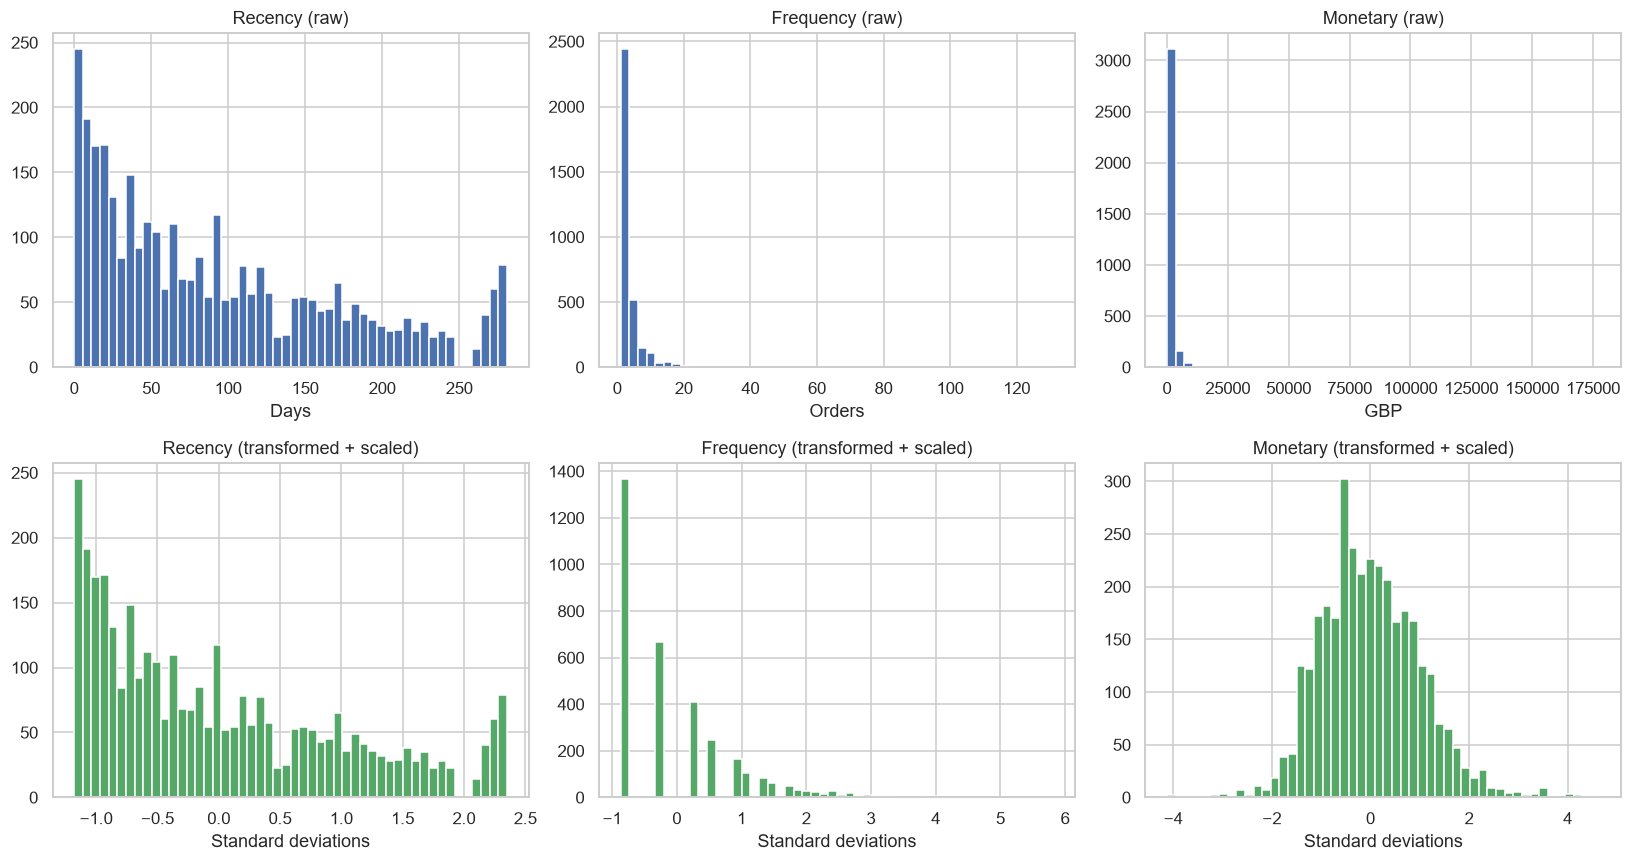

In [10]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
for j, (col, lab) in enumerate(zip(RAW_COLS, ["Days", "Orders", "GBP"])):
    ax[0, j].hist(rfm[col], bins=50, color="#4C72B0")
    ax[0, j].set_title(f"{col} (raw)"); ax[0, j].set_xlabel(lab)
for j, col in enumerate(FEATURES):
    ax[1, j].hist(rfm[col], bins=50, color="#55A868")
    ax[1, j].set_title(col.replace("_scaled", " (transformed + scaled)"))
    ax[1, j].set_xlabel("Standard deviations")
save_fig("rfm_before_after")

## 6. Baseline and clustering methods  *(Member 3)*

The rule-based RFM score is the baseline every machine-learning method must beat.
It uses quintile scores (1–5) on each of R, F and M, summed and banded into four groups.

In [11]:
X = rfm[FEATURES].to_numpy(float)

def rfm_baseline(frame):
    out = pd.DataFrame(index=frame.index)
    for col, ascending in [("Recency", False), ("Frequency", True), ("Monetary", True)]:
        ranks = frame[col].rank(ascending=ascending, method="average")
        p = (ranks - 0.5) / len(frame)
        out[col[0] + "_Score"] = np.clip(np.floor(5 * p) + 1, 1, 5).astype(int)
    out["Total"] = out[["R_Score", "F_Score", "M_Score"]].sum(axis=1)
    out["Group"] = pd.cut(out.Total, [2, 6, 9, 12, 15], labels=[0, 1, 2, 3]).astype(int)
    return out

def metrics(X, labels):
    return {"silhouette":        silhouette_score(X, labels),
            "davies_bouldin":    davies_bouldin_score(X, labels),
            "calinski_harabasz": calinski_harabasz_score(X, labels),
            "smallest_cluster":  int(pd.Series(labels).value_counts().min()),
            "largest_cluster":   int(pd.Series(labels).value_counts().max())}

def fit(method, k, X, seed=SEED):
    if method == "KMeans":
        m = KMeans(n_clusters=k, init="k-means++", n_init=20,
                   max_iter=500, tol=1e-4, random_state=seed).fit(X)
    elif method == "Hierarchical":
        m = AgglomerativeClustering(n_clusters=k, linkage="ward").fit(X)
    else:
        m = GaussianMixture(n_components=k, covariance_type="full", n_init=10,
                            max_iter=500, tol=1e-3, reg_covar=1e-6,
                            random_state=seed).fit(X)
    labels = m.predict(X) if method == "GMM" else m.labels_
    return m, labels

baseline_labels = rfm_baseline(rfm).Group.to_numpy()
rows = [{"method": "RFM_Baseline", "k": 4, **metrics(X, baseline_labels)}]

COUNTS = range(2, 9)
fitted = {}
for method in ["KMeans", "Hierarchical", "GMM"]:
    for k in COUNTS:
        model, labels = fit(method, k, X)
        fitted[(method, k)] = (model, labels)
        rows.append({"method": method, "k": k, **metrics(X, labels)})

results = pd.DataFrame(rows)
display(results.round(4))

,method,k,silhouette,davies_bouldin,calinski_harabasz,smallest_cluster,largest_cluster
0,RFM_Baseline,4,0.22,1.42,"2,097.52",719,935
1,KMeans,2,0.41,0.90,"3,136.79",1395,1967
2,KMeans,3,0.37,0.92,"3,135.75",866,1520
3,KMeans,4,0.35,0.95,"3,039.66",470,1112
4,KMeans,5,0.32,0.99,"2,768.89",184,965
5,KMeans,6,0.31,0.97,"2,662.28",190,758
6,KMeans,7,0.30,0.98,"2,528.25",184,725
7,KMeans,8,0.28,1.05,"2,409.55",134,617
8,Hierarchical,2,0.39,0.95,"2,896.43",1645,1717
9,Hierarchical,3,0.34,0.93,"2,565.99",380,1645


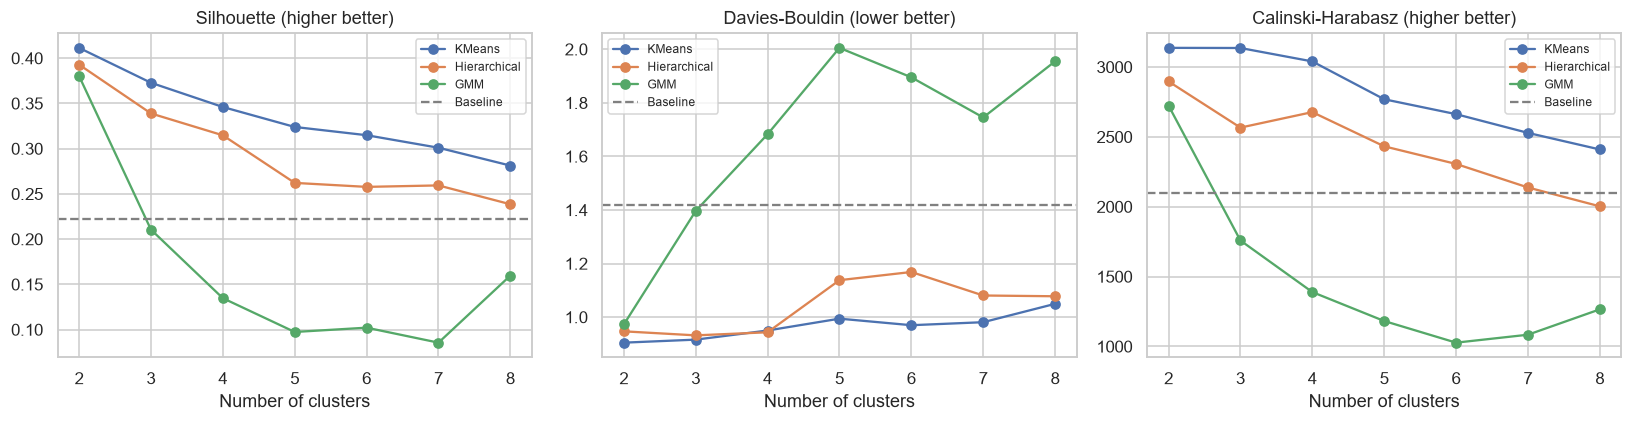

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, metric, title in zip(ax, ["silhouette", "davies_bouldin", "calinski_harabasz"],
                            ["Silhouette (higher better)", "Davies-Bouldin (lower better)",
                             "Calinski-Harabasz (higher better)"]):
    for method in ["KMeans", "Hierarchical", "GMM"]:
        sub = results[results.method == method]
        a.plot(sub.k, sub[metric], marker="o", label=method)
    a.axhline(results.loc[0, metric], ls="--", c="grey", label="Baseline")
    a.set_title(title); a.set_xlabel("Number of clusters"); a.legend(fontsize=8)
save_fig("method_comparison")

### 6.1 Stability across random seeds

A method whose groups change with the starting seed cannot be trusted. Each stochastic
configuration is refitted at five seeds and all ten pairwise Adjusted Rand Index values
are compared. ARI of 1.0 means an identical partition.

In [13]:
stab = []
for method in ["KMeans", "GMM"]:
    for k in COUNTS:
        runs = [fit(method, k, X, seed=s)[1] for s in SEEDS]
        pairs = [adjusted_rand_score(runs[i], runs[j])
                 for i in range(len(runs)) for j in range(i+1, len(runs))]
        stab.append({"method": method, "k": k, "ari_mean": np.mean(pairs),
                     "ari_min": np.min(pairs), "pairs": len(pairs)})
stability = pd.DataFrame(stab)
results = results.merge(stability, on=["method", "k"], how="left")
display(stability.round(4))
print("Hierarchical clustering is deterministic, so seed stability does not apply to it.")

,method,k,ari_mean,ari_min,pairs
0,KMeans,2,1.00,1.00,10
1,KMeans,3,1.00,1.00,10
2,KMeans,4,0.99,0.98,10
3,KMeans,5,1.00,0.99,10
4,KMeans,6,0.97,0.96,10
5,KMeans,7,0.99,0.99,10
6,KMeans,8,0.87,0.72,10
7,GMM,2,1.00,1.00,10
8,GMM,3,1.00,1.00,10
9,GMM,4,1.00,1.00,10


Hierarchical clustering is deterministic, so seed stability does not apply to it.


## 7. Candidate shortlist  *(Member 3)*

K-Means k=2 leads every geometric metric. K-Means k=3 is retained as the finer
alternative, with Ward and GMM at k=2 as cross-method comparators. GMM k=8 is kept
only as a density diagnostic: AIC and BIC prefer it, but its separation is poor and
its seed stability is weak, which is itself worth reporting.

In [14]:
CANDIDATES = {
    "RFM_Baseline_Group": baseline_labels,
    "KMeans_k2":          fitted[("KMeans", 2)][1],
    "KMeans_k3":          fitted[("KMeans", 3)][1],
    "Hierarchical_k2":    fitted[("Hierarchical", 2)][1],
    "GMM_k2":             fitted[("GMM", 2)][1],
    "GMM_k8_Diagnostic":  fitted[("GMM", 8)][1],
}

best = results.loc[results.silhouette.idxmax()]
leader = results[(results.method == "KMeans") & (results.k == 2)].iloc[0]
print(f"Highest silhouette overall: {best.method} k={int(best.k)} ({best.silhouette:.4f})")
print(f"KMeans k=2                : {leader.silhouette:.4f}")
if not np.isclose(leader.silhouette, results.silhouette.max()):
    print("\nNOTE: KMeans k=2 is no longer the silhouette leader on this run.")
    print("Section 9 argues from k=2 being the geometric leader, so re-read that")
    print("reasoning against the table above before quoting it in the report.")
else:
    print("Matches the write-up in section 9.")

assignments = rfm[["CustomerID", *RAW_COLS]].copy()
for name, labels in CANDIDATES.items():
    assignments[name] = labels
assignments.to_csv(PROCESSED/"cluster_assignments.csv", index=False)

def profile(labels, name):
    out = rfm.groupby(labels).agg(
        customers=("CustomerID", "count"),
        median_recency=("Recency", "median"), median_frequency=("Frequency", "median"),
        median_monetary=("Monetary", "median"), mean_monetary=("Monetary", "mean"),
    ).reset_index(drop=True)
    out.insert(0, "solution", name)
    out.insert(1, "cluster", range(len(out)))
    out.insert(3, "percent", 100 * out.customers / len(rfm))
    return out

all_profiles = pd.concat([profile(l, n) for n, l in CANDIDATES.items()], ignore_index=True)
display(all_profiles.round(2))
assert len(assignments) == len(rfm)
print(f"\nHandoff to Member 4 verified: {len(assignments):,} customers, 6 candidate solutions.")

Highest silhouette overall: KMeans k=2 (0.4114)
KMeans k=2                : 0.4114
Matches the write-up in section 9.


,solution,cluster,customers,percent,median_recency,median_frequency,median_monetary,mean_monetary
0,RFM_Baseline_Group,0,935,27.81,182.00,1.00,190.55,220.71
1,RFM_Baseline_Group,1,905,26.92,88.00,2.00,409.63,606.16
2,RFM_Baseline_Group,2,803,23.88,46.00,3.00,905.60,"1,228.49"
3,RFM_Baseline_Group,3,719,21.39,15.00,7.00,"2,433.22","5,034.78"
4,KMeans_k2,0,1967,58.51,125.00,1.00,304.10,385.48
5,KMeans_k2,1,1395,41.49,27.00,4.00,"1,561.06","3,299.77"
6,KMeans_k3,0,866,25.76,22.00,6.00,"2,284.96","4,720.23"
7,KMeans_k3,1,976,29.03,192.00,1.00,246.27,340.63
8,KMeans_k3,2,1520,45.21,58.00,2.00,498.48,619.25
9,Hierarchical_k2,0,1717,51.07,32.00,4.00,"1,228.19","2,780.91"



Handoff to Member 4 verified: 3,362 customers, 6 candidate solutions.


## 8. Three-month future validation  *(Member 4)*

This is the strongest evidence in the project. Cluster quality scores only describe
geometry. This section asks whether the groups actually behaved differently in the
91 days after the cut-off — data no model has seen.

The future window was cleaned by the **same function** as the historical window
in section 4.

In [15]:
future["TotalSpend"] = future.Quantity * future.UnitPrice
outcomes = future.groupby("CustomerID").agg(
    Future_Orders=("InvoiceNo",  "nunique"),
    Future_Spend =("TotalSpend", "sum"),
).reset_index()
outcomes["Returned"] = 1

merged = assignments.merge(outcomes, on="CustomerID", how="left")
for col, fill in [("Future_Orders", 0), ("Future_Spend", 0.0), ("Returned", 0)]:
    merged[col] = merged[col].fillna(fill)

assert len(merged) == len(assignments), "Join changed the row count"
for name in CANDIDATES:
    assert merged[name].equals(assignments[name]), f"Leakage: {name} was modified"
print("Leakage guard passed: future outcomes were joined on, never fed back into the model.\n")

window_days = (raw.InvoiceDate.max() - CUTOFF).days
print(f"Validation window : {CUTOFF.date()} to {raw.InvoiceDate.max().date()} ({window_days} days)")
print(f"Customers tracked : {len(merged):,}")
print(f"Returned          : {int(merged.Returned.sum()):,} ({merged.Returned.mean()*100:.1f}%)")
print(f"Did not return    : {int((1-merged.Returned).sum()):,}")
print("\nCustomers who first appeared after the cut-off are excluded by design:")
print("they had no historical behaviour to segment on.")

Leakage guard passed: future outcomes were joined on, never fed back into the model.

Validation window : 2011-09-09 to 2011-12-09 (91 days)
Customers tracked : 3,362
Returned          : 1,920 (57.1%)
Did not return    : 1,442

Customers who first appeared after the cut-off are excluded by design:
they had no historical behaviour to segment on.


In [16]:
def validate(name):
    out = merged.groupby(name).agg(
        customers      =("CustomerID",    "count"),
        repeat_rate    =("Returned",      "mean"),
        median_orders  =("Future_Orders", "median"),
        median_spend   =("Future_Spend",  "median"),
        total_spend    =("Future_Spend",  "sum"),
    ).reset_index().rename(columns={name: "cluster"})
    out.insert(0, "solution", name)
    return out

validated = pd.concat([validate(n) for n in
                       ["RFM_Baseline_Group", "KMeans_k2", "KMeans_k3",
                        "Hierarchical_k2", "GMM_k2"]], ignore_index=True)
validated["repeat_rate"] = (validated.repeat_rate * 100).round(1)
display(validated.round(2))

print("\nSpread in repeat-purchase rate between a solution's best and worst cluster")
print("(a wider spread means the segmentation separates future behaviour better):")
for name, grp in validated.groupby("solution", sort=False):
    print(f"  {name:<22} {grp.repeat_rate.max() - grp.repeat_rate.min():>5.1f} "
          f"percentage points  (k={len(grp)})")

,solution,cluster,customers,repeat_rate,median_orders,median_spend,total_spend
0,RFM_Baseline_Group,0,935,34.70,0.00,0.00,"305,572.85"
1,RFM_Baseline_Group,1,905,46.20,0.00,0.00,"326,595.19"
2,RFM_Baseline_Group,2,803,67.40,1.00,304.50,"428,479.70"
3,RFM_Baseline_Group,3,719,88.60,3.00,977.16,"1,768,423.25"
4,KMeans_k2,0,1967,42.10,0.00,0.00,"681,988.98"
5,KMeans_k2,1,1395,78.20,2.00,622.26,"2,147,082.01"
6,KMeans_k3,0,866,87.00,2.00,958.02,"1,903,514.42"
7,KMeans_k3,1,976,34.40,0.00,0.00,"357,352.32"
8,KMeans_k3,2,1520,54.70,1.00,119.07,"568,204.25"
9,Hierarchical_k2,0,1717,74.30,1.00,493.80,"2,252,983.11"



Spread in repeat-purchase rate between a solution's best and worst cluster
(a wider spread means the segmentation separates future behaviour better):
  RFM_Baseline_Group      53.9 percentage points  (k=4)
  KMeans_k2               36.1 percentage points  (k=2)
  KMeans_k3               52.6 percentage points  (k=3)
  Hierarchical_k2         35.2 percentage points  (k=2)
  GMM_k2                  34.0 percentage points  (k=2)


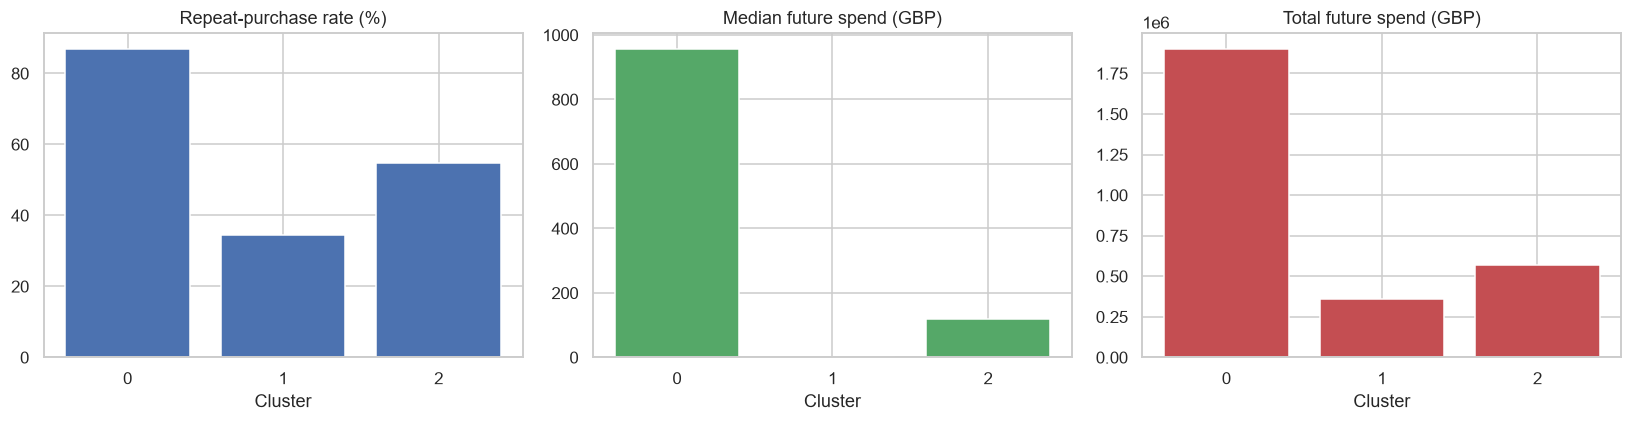

In [17]:
k3 = validated[validated.solution == "KMeans_k3"]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(k3.cluster.astype(str), k3.repeat_rate, color="#4C72B0")
ax[0].set_title("Repeat-purchase rate (%)"); ax[0].set_xlabel("Cluster")
ax[1].bar(k3.cluster.astype(str), k3.median_spend, color="#55A868")
ax[1].set_title("Median future spend (GBP)"); ax[1].set_xlabel("Cluster")
ax[2].bar(k3.cluster.astype(str), k3.total_spend, color="#C44E52")
ax[2].set_title("Total future spend (GBP)"); ax[2].set_xlabel("Cluster")
save_fig("future_validation_k3")

## 9. Final model selection  *(Member 4)*

**Chosen: K-Means with k=3.**

K-Means k=2 wins on every geometric score, so choosing k=3 needs justification.
Geometry measures whether points sit in tidy blobs; it does not measure whether the
groups are *useful*. Three pieces of evidence favour k=3:

1. **It isolates the VIP tier.** At k=2 the highest-value customers are diluted into a
   broad "active" group. At k=3 they form a cluster of their own, and that cluster
   generates the large majority of future revenue.
2. **It survives the future test.** All three clusters behave measurably differently in
   the 91-day window, so the extra split is real rather than cosmetic.
3. **It maps to three distinct actions.** The manager can reward, upsell and win back.
   Two groups would collapse the first two into one.

k=3 remains highly stable (ARI above 0.99) and its silhouette is close behind k=2.
This is recorded as decision **D12**.

In [18]:
FINAL = "KMeans_k3"
final_profile = (all_profiles[all_profiles.solution == FINAL]
                 .merge(validated[validated.solution == FINAL].drop(columns="solution"),
                        on="cluster", suffixes=("", "_future")))
display(final_profile.round(2))

order = final_profile.sort_values("median_monetary", ascending=False).cluster.tolist()
names = {order[0]: "Champions",
         order[1]: "Regulars / Developing",
         order[2]: "At risk / Inactive"}
actions = {"Champions":            "Reward and protect. VIP access, not discounts",
           "Regulars / Developing":"Upsell. Recommendations and volume offers",
           "At risk / Inactive":   "Win back. Reactivation offer, then stop spending"}

summary = final_profile.assign(
    Segment=final_profile.cluster.map(names),
    Action =final_profile.cluster.map(names).map(actions))[
    ["cluster", "Segment", "customers", "percent", "median_recency", "median_frequency",
     "median_monetary", "repeat_rate", "median_spend", "total_spend", "Action"]]
display(summary.round(1))
summary.to_csv(PROCESSED/"final_segments.csv", index=False)

share = 100 * summary.set_index("Segment").total_spend / summary.total_spend.sum()
print("\nShare of future revenue by segment:")
for seg, v in share.items():
    print(f"  {seg:<24} {v:5.1f}%")

,solution,cluster,customers,percent,median_recency,median_frequency,median_monetary,mean_monetary,customers_future,repeat_rate,median_orders,median_spend,total_spend
0,KMeans_k3,0,866,25.76,22.00,6.00,"2,284.96","4,720.23",866,87.00,2.00,958.02,"1,903,514.42"
1,KMeans_k3,1,976,29.03,192.00,1.00,246.27,340.63,976,34.40,0.00,0.00,"357,352.32"
2,KMeans_k3,2,1520,45.21,58.00,2.00,498.48,619.25,1520,54.70,1.00,119.07,"568,204.25"


,cluster,Segment,customers,percent,median_recency,median_frequency,median_monetary,repeat_rate,median_spend,total_spend,Action
0,0,Champions,866,25.80,22.00,6.00,"2,285.00",87.00,958.00,"1,903,514.40","Reward and protect. VIP access, not discounts"
1,1,At risk / Inactive,976,29.00,192.00,1.00,246.30,34.40,0.00,"357,352.30","Win back. Reactivation offer, then stop spending"
2,2,Regulars / Developing,1520,45.20,58.00,2.00,498.50,54.70,119.10,"568,204.30",Upsell. Recommendations and volume offers



Share of future revenue by segment:
  Champions                 67.3%
  At risk / Inactive        12.6%
  Regulars / Developing     20.1%


## 10. Recommendation and limitations  *(Members 1 and 4)*

### What the shop should do

**Champions** — the smallest group but the source of most future revenue. Protect them
with early access and reliable service rather than discounts; they buy anyway, so a
discount is margin given away.

**Regulars / Developing** — the largest group and the biggest opportunity. They are
active but buy less. Recommendations and volume offers aimed at moving even a fraction
of them toward Champion behaviour is where growth comes from.

**At risk / Inactive** — send one reactivation offer, measure the response, and stop
spending on non-responders. Telling a business who *not* to spend on is as valuable
as telling it who to chase.

Member 1's EDA found that roughly a third of all customers ordered once and never
returned. Converting even a small share of them into second-time buyers would be a
substantial gain without acquiring a single new customer.

### Limitations

Stated plainly, because they bound what the shop should conclude.

1. **A quarter of transactions have no customer attached.** These segments describe
   identified customers only. If guest buyers behave differently, the picture is partial.
2. **The validation window contains Christmas.** Repeat-purchase rates in the 91-day
   window are higher than a normal quarter would produce. Comparisons *between* segments
   stay fair because all share the window, but the absolute rates are not typical.
3. **One year of data.** Seasonality cannot be separated from business growth.
4. **Revenue, not profit.** No cost data exists, so "value" means turnover.
5. **No demographics or marketing history.** The model describes what customers did,
   never why.
6. **No ground truth.** Clustering has no correct answer. The future test is evidence
   of usefulness, not proof of correctness.
7. **Segments are a snapshot.** Customers move between groups over time, so the
   segmentation needs periodic rebuilding.

## 11. Reproducibility and AI-use declaration

### Reproducibility

- Raw file verified by SHA-256 against the fingerprint recorded by Member 1.
- One random seed (42) is used by every stochastic model.
- Both time windows are cleaned by a single shared function, so they cannot drift apart.
- Assertions guard each handoff and both leakage risks; the notebook fails loudly
  rather than producing quietly wrong numbers.
- Runs top to bottom from the raw file with no manual steps.

**Before submitting:** restart the kernel, run everything, and confirm that every figure
quoted in the report matches this run.

### AI-use declaration

*Replace this with your group's own honest account. Name which parts of the work used
AI assistance and what each member verified independently. The descriptor requires an
honest declaration and it contributes to the reproducibility marks.*

In [19]:
print("=" * 62)
print("FINAL RUN SUMMARY")
print("=" * 62)
print(f"Raw rows                 : {len(raw):,}")
print(f"Historical rows (cleaned): {len(hist):,}")
print(f"Future rows (cleaned)    : {len(future):,}")
print(f"Customers segmented      : {len(rfm):,}")
print(f"Final model              : {FINAL} (k=3)")
print(f"Validation window        : {window_days} days")
print(f"Repeat-purchase rate     : {merged.Returned.mean()*100:.1f}%")
print(f"Dataset SHA-256          : {FINGERPRINT}")
print()
print("Outputs written:")
for p in ["data/interim/cleaned_transactions.csv", "data/processed/rfm_table.csv",
          "data/processed/cluster_assignments.csv", "data/processed/final_segments.csv",
          "docs/reproducibility/final_run_record.json", "figures/final/"]:
    print("  " + p)

FINAL RUN SUMMARY
Raw rows                 : 541,909
Historical rows (cleaned): 231,806
Future rows (cleaned)    : 159,638
Customers segmented      : 3,362
Final model              : KMeans_k3 (k=3)
Validation window        : 91 days
Repeat-purchase rate     : 57.1%
Dataset SHA-256          : 43465a06f2ccf7c8b5bd2892bc7defb52f97487934fe93b16ae4c3936424676d

Outputs written:
  data/interim/cleaned_transactions.csv
  data/processed/rfm_table.csv
  data/processed/cluster_assignments.csv
  data/processed/final_segments.csv
  docs/reproducibility/final_run_record.json
  figures/final/
